LexRank Algorithm is an Extractive-based text summarization method. In the LexRank algorithm, a sentence that is similar to many other sentences of the text has a high probability of being important. The approach is that a particular sentence is recommended by other similar sentences and hence is ranked higher. This method is based on Eigen Vector centrally. It follows an approach of a connected graph. Sentences are placed on vertices of the graph. The weight on the Edges is calculated using a cosine similarity metric

- Retrieve data from the Reuters corpus

- Train a LexRank model using this dataset


In [ ]:
import numpy as np
import nltk
nltk.download('punkt')
nltk.download('reuters')
#nltk.download('punkt_tab')

from nltk.corpus import reuters
from nltk.tokenize import sent_tokenize
from lexrank import LexRank
from lexrank.mappings.stopwords import STOPWORDS


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Justine\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package reuters to
[nltk_data]     C:\Users\Justine\AppData\Roaming\nltk_data...
[nltk_data]   Package reuters is already up-to-date!


In [38]:
documents = []
for fileid in reuters.fileids()[:1000]: 
    raw_text = reuters.raw(fileid)
    sentences = sent_tokenize(raw_text)
    documents.append(sentences)

lxr = LexRank(documents, stopwords=STOPWORDS['en'])


Testing LexRank with a financial article from Reuters

[Google unveils AI upgrades at I/O conference amid search challenges — Reuters (May 20, 2025)](https://www.reuters.com/business/google-unveil-ai-upgrades-io-conference-amid-search-challenges-2025-05-20/)

In [53]:
text = """
MOUNTAIN VIEW, California, May 20 (Reuters) - Alphabet's (GOOGL.O), opens new tab Google said on Tuesday it would put artificial intelligence into the hands of more Web surfers while teasing a $249.99-a-month subscription for its AI power users, its latest effort to fend off growing competition from startups like OpenAI.
Google unveiled the plans amid a flurry of demos that included new smart glasses during its annual I/O conference in Mountain View, California, which has adopted a tone of increased urgency since the rise of generative AI challenged the tech company's longtime stronghold of organizing and retrieving information on the internet.
In recent months, Google has become more aggressive in asserting it has caught up to competitors after appearing flat-footed upon the release of Microsoft-backed (MSFT.O), opens new tab OpenAI's ChatGPT in 2022.
On Tuesday, it further laid out a vision for Google Search that lets consumers ask virtually anything, from simple queries to complex research questions, from analyzing what a smartphone camera sees to fetching an event ticket to buy.
Google likewise said it aims to build AI that is personal and proactive, whether phoning a store for users or sending students a practice test generated on the fly.
CEO Sundar Pichai said at the conference that Alphabet would build such AI with the cost in mind as well. "Over and over, we've been able to deliver the best models at the most effective price point," he said.
Google's AI assistant Gemini app now has more than 400 million monthly active users, Pichai said.
In a major update, the company said consumers across the United States now can switch Google Search into “AI Mode.”
Showcased in March, opens new tab as an experiment open to test users, the feature dispenses with the Web’s standard fare in favor of computer-generated answers for complicated queries.
Google also announced an “AI Ultra Plan,” which for $249.99 monthly provides users with higher limits on AI and early access to experimental tools like Project Mariner, an internet browser extension that can automate keystrokes and mouse clicks, and Deep Think, a version of its top-shelf Gemini model that is more capable of reasoning through complicated tasks.
The price is comparable to $200 monthly plans from AI model developers OpenAI and Anthropic, underscoring how companies are exploring ways to pay for the exorbitant price tag of AI development.
Google's new plan also includes 30 terabytes of cloud storage and an ad-free YouTube subscription. Google already offers other subscription options, including a $19.99-per-month service with access to some AI capabilities unavailable for most free users and cheaper plans with additional cloud storage. Last week, the company told Reuters it had signed up more than 150 million subscribers across those plans.
Pichai told reporters that the rise of generative AI was not at the full expense of online search.
This “feels very far from a zero-sum moment,” said Pichai. “The kind of use cases we are serving in search is dramatically expanding” because of AI.
Alphabet shares closed 1.5% lower at $165.32 on Tuesday. Google made a return to a bumpy effort years ago around smart glasses, demonstrating frames with its new Android XR software. Since its early efforts, rival Meta Platforms (META.O)
, opens new tab has brought its own glasses with AI to market.
On stage, two Google officials had a conversation in different languages while the glasses typed up translations for them, viewed through the frames' lenses.
Gemini, meanwhile, answered queries about one of the wearer's surroundings as she walked around Mountain View's Shoreline Amphitheater.
An XR headset being developed in partnership with Samsung (005930.KS)
, opens new tab will launch later this year, an official said. Google also announced new partnerships with glasses designers Warby Parker and Gentle Monster to develop headsets with Android XR. Earlier this month, Alphabet stock lost $150 billion in market value in one day after an Apple (AAPL.O)
, opens new tab executive testified during one of Google's antitrust cases that AI offerings had caused a decline in searches on Apple's Safari Web browser for the first time.
In turn, some analysts reassessed how to measure Google's dominant search market share, with one estimate stating it could fall to less than 50% from around 90% in five years. The analysts cited a behavioral shift drawing consumers toward AI chatbots where they once used traditional search engines.
However, Robby Stein, an executive on the search team, in an interview said allowing users to answer more challenging questions through AI could enable "new opportunities to create hyper-relevant, useful advertising." Ads make up the majority of Google's revenue.
Investment in AI accounts for most of Alphabet's $75 billion in forecasted capital expenditures this year, a dramatic uptick from the $52.5 billion in 2024 spending that the company reported.
Tuesday's announcements included further updates to Google's work to deliver a "universal AI agent," which can perform tasks on someone’s behalf without additional prompting.
In a number of demos, Google drew on capabilities developed in a testing ground it has called Project Astra to show off what its latest AI could do.
These included pointing a smartphone camera at a written invitation and having AI add the event to a user’s calendar.
Google also presented a new AI model called Veo 3 that generates video and audio to create more realistic film snippets for creators.
"""


#tokenize the long text into individual sentences
sentences = sent_tokenize(text)

#execute the model with our text
summary = lxr.get_summary(sentences, summary_size=3, threshold=0.2)


print("\nSummary:")
for line in summary:
    print("-", line)



Summary:
- Google already offers other subscription options, including a $19.99-per-month service with access to some AI capabilities unavailable for most free users and cheaper plans with additional cloud storage.
- Pichai told reporters that the rise of generative AI was not at the full expense of online search.
- Google also announced an “AI Ultra Plan,” which for $249.99 monthly provides users with higher limits on AI and early access to experimental tools like Project Mariner, an internet browser extension that can automate keystrokes and mouse clicks, and Deep Think, a version of its top-shelf Gemini model that is more capable of reasoning through complicated tasks.


The summary produced by LexRank accurately reflects several important points, notably the premium subscription offers, Sundar Pichai’s remarks on the impact of AI on search, and new tools such as the “AI Ultra Plan.” These sentences are coherent and informative.

However, compared to the benchmark summary, it can be observed that LexRank does not cover certain strategic ideas such as the rise of competition, the possible decline in Google’s market share, or the more forward-looking aspects of innovations (glasses, universal assistants). Important information may thus be omitted by LexRank. This is explained by the extractive nature of LexRank, which is based on the frequency and connectivity of sentences in the text without necessarily understanding their significance or overall context

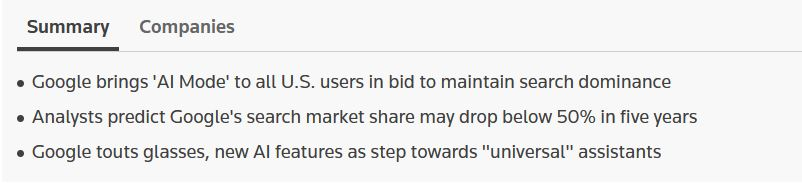

In [59]:
scores_cont = lxr.rank_sentences(
    sentences,
    threshold=None,
    fast_power_method=False,
)
print(scores_cont)

[1.39993174 1.14870554 0.75309979 0.87911583 1.23792416 1.24080983
 0.35253496 1.53331193 1.39385559 1.44775121 1.31912022 0.62090953
 1.48791004 0.3935379  1.42040197 0.47178559 1.3208206  0.46643258
 0.85972352 1.17183328 0.73687516 0.42366109 0.61459795 0.77260369
 1.18874631 0.73588596 1.17662648 1.15871725 0.57045896 1.00931893
 1.05954972 1.28418041 1.18300466 1.16625765]


Our summary missed out of the sentence to smart glasses. What is her score ?

In [69]:
target_sentence = "Google unveiled the plans amid a flurry of demos that included new smart glasses during its annual I/O conference in Mountain View, California, which has adopted a tone of increased urgency since the rise of generative AI challenged the tech company's longtime stronghold of organizing and retrieving information on the internet."
flag = True

try:
    index = sentences.index(target_sentence)
    print(f"Score of target sentence : {scores_cont[index]:.3f}")
except ValueError:
    print("This sentence does not appear in the text")
    flag = False


Score of target sentence : 1.149


What is her classement from the tokeniser setences ?

In [70]:
if flag : 
    index = sentences.index(target_sentence)
    score = scores_cont[index]
    
    #Sort score clues and find the position of the cilblated phrase
    sorted_indices = np.argsort(scores_cont)[::-1]
    rank = np.where(sorted_indices == index)[0][0] + 1
    
    print(f"This sentence is ranked {rank}/{len(sentences)} with a score of {score:.3f} ")

This sentence is ranked 18/34 with a score of 1.149 


The topic of smart glasses appears only in a few sentences throughout the article, making it relatively infrequent. As a result, LexRank assigns it a lower importance score because it relies on the frequency and connectivity of sentences. Since this subject does not have strong presence or connections in the text, LexRank does not recognize it as a central theme, which explains the moderate ranking of related sentences